In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# Load dataset
df = pd.read_csv("../data/processed/stg_delivery_fee_movement.csv")

In [14]:
# Data inspection
def first_look(df):
    print(f"Shape: {df.shape}")
    print(f"\nColumn types:\n{df.dtypes}")
    print(f"\nMissing values (%):\n{(df.isnull().mean() * 100).round(1)}")
    print(f"\nDuplicates: {df.duplicated().sum()}")
    print(f"\nFirst 5 rows:\n{df.head()}")
    print(f"\nBasic stats:\n{df.describe(include='all')}")

first_look(df)

Shape: (217222, 5)

Column types:
date                  str
City                  str
restaurant_id       int64
Distance(KM)        int64
DeliveryFee($)    float64
dtype: object

Missing values (%):
date              0.0
City              0.0
restaurant_id     0.0
Distance(KM)      0.0
DeliveryFee($)    0.0
dtype: float64

Duplicates: 0

First 5 rows:
         date   City  restaurant_id  Distance(KM)  DeliveryFee($)
0  2025-03-01  Omaha              0             0            4.25
1  2025-03-01  Omaha              0             3            4.75
2  2025-03-01  Omaha              0             5            5.75
3  2025-03-01  Omaha              0             6            6.25
4  2025-03-01  Omaha              0             8            7.25

Basic stats:
              date    City  restaurant_id  Distance(KM)  DeliveryFee($)
count       217222  217222  217222.000000  217222.00000   217222.000000
unique          31       2            NaN           NaN             NaN
top     2025-03-30  

In [15]:
# Clean data
df["date"] = pd.to_datetime(df["date"])

# Overall Delivery Fee Trends

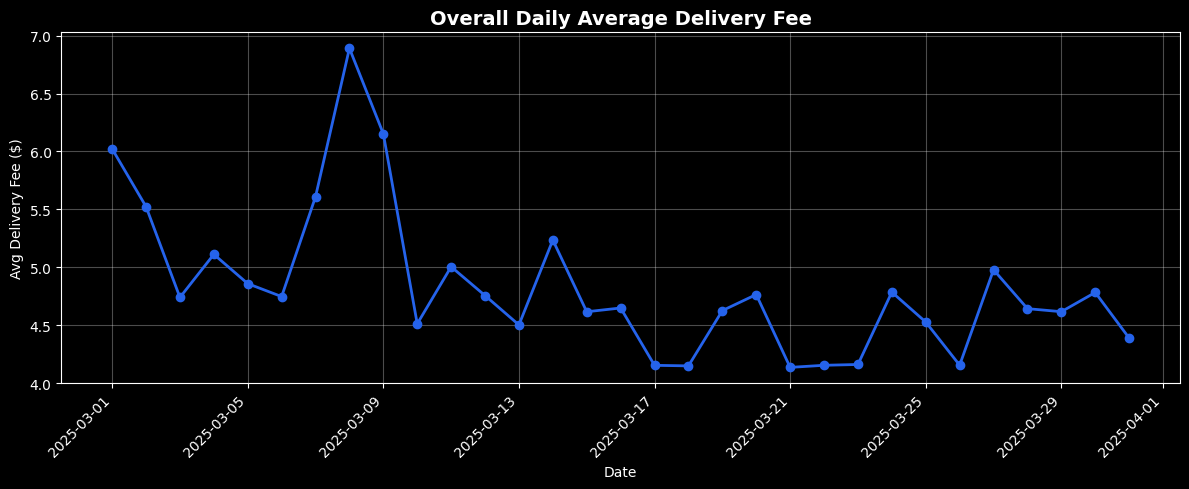

In [16]:
# 1.1) Overall Daily Average Delivery Fee
daily_avg = df.groupby("date")["DeliveryFee($)"].mean()

fig1, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(
    daily_avg.index, daily_avg.values, marker="o", linewidth=2, color="#2563EB"
)
ax1.set_title("Overall Daily Average Delivery Fee", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date")
ax1.set_ylabel("Avg Delivery Fee ($)")
ax1.grid(True, alpha=0.3)
fig1.autofmt_xdate(rotation=45)
fig1.tight_layout()

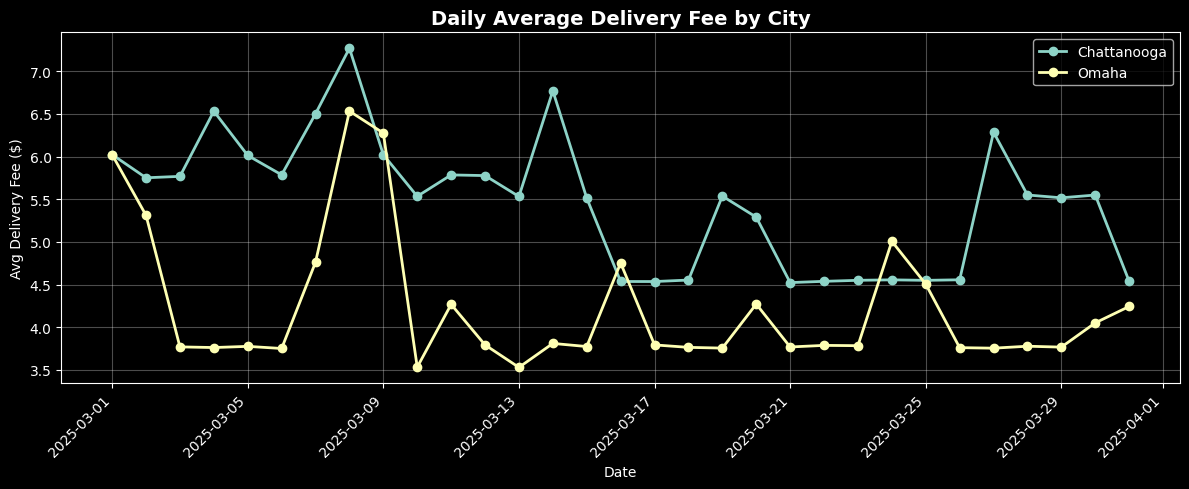

In [17]:
# 1.2) Daily Average Delivery Fee by City trends
city_daily = df.groupby(["date", "City"])["DeliveryFee($)"].mean().unstack("City")

fig2, ax2 = plt.subplots(figsize=(12, 5))
for city in city_daily.columns:
    ax2.plot(
        city_daily.index, city_daily[city], marker="o", linewidth=2, label=city
    )
ax2.set_title("Daily Average Delivery Fee by City", fontsize=14, fontweight="bold")
ax2.set_xlabel("Date")
ax2.set_ylabel("Avg Delivery Fee ($)")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig2.autofmt_xdate(rotation=45)
fig2.tight_layout()

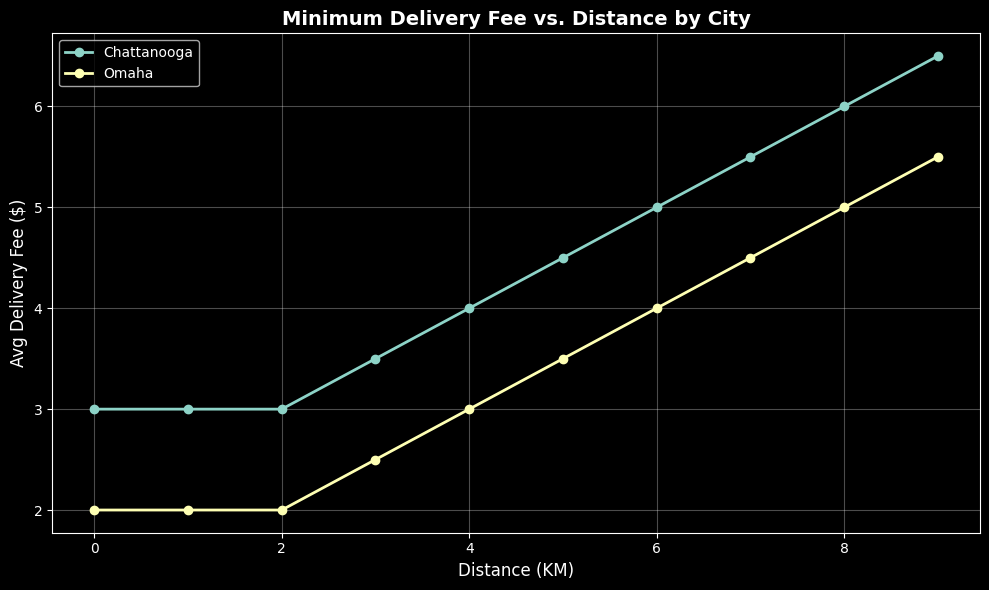

In [18]:
# 1.3) Delivery fee trends by distance and city
_df = df.copy()

city_distance = (
    _df.groupby(["Distance(KM)", "City"])["DeliveryFee($)"]
    .min()
    .unstack("City")
)

fig3, ax3 = plt.subplots(figsize=(10, 6))

for city in city_distance.columns:
    ax3.plot(
        city_distance.index, city_distance[city], marker="o", linewidth=2, label=city
    )
ax3.set_title(
    "Minimum Delivery Fee vs. Distance by City"     , fontsize=14, fontweight="bold"
)
ax3.set_xlabel("Distance (KM)", fontsize=12)
ax3.set_ylabel("Avg Delivery Fee ($)", fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.3)

fig3.tight_layout()

Figure 2: We can see that there is an incremental after 2km of $0.50 per KM. Therefore, the first 2 KM is free of distance fee then +$0.50 every KM.

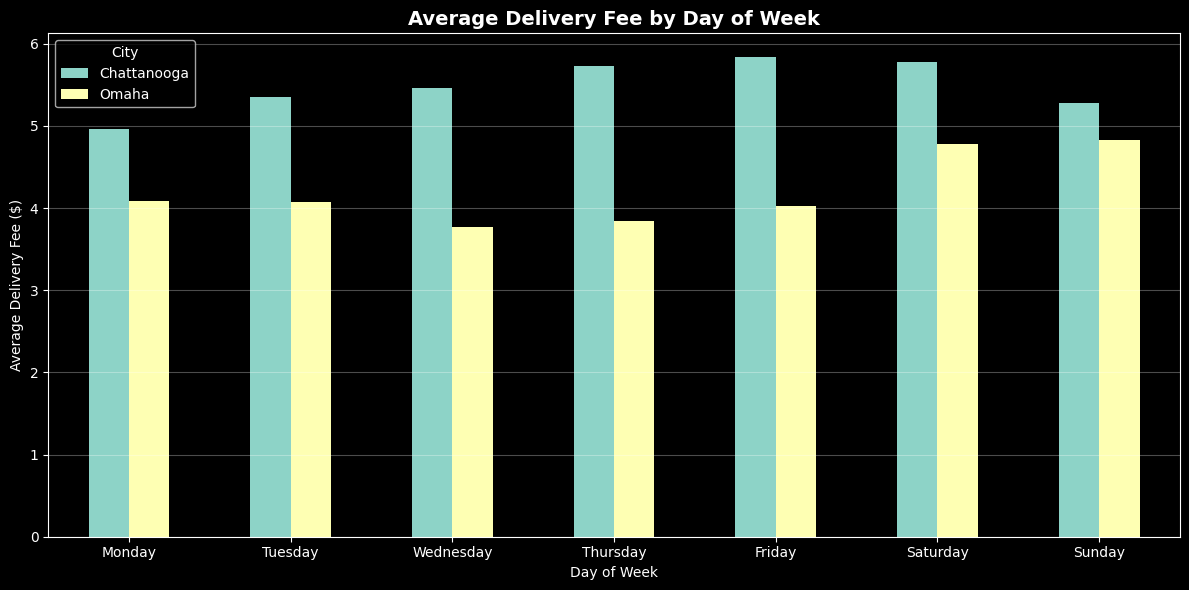

In [19]:
# 1.4) Weekend trends

# Create day of week
df["Day_Number"] = df["date"].dt.dayofweek # Order of the day
df["Day_of_Week"] = df["date"].dt.day_name()
df["Is_Weekend"] = df["Day_of_Week"].isin(["Saturday", "Sunday"])

# Calc
weekday_avg = (
    df.groupby(["Day_Number", "Day_of_Week", "City"])["DeliveryFee($)"]
    .mean()
    .unstack("City")
    .sort_index(level=0)
)


# Plot (Bar)
fig4, ax4 = plt.subplots(figsize=(12, 6))

weekday_avg.plot(kind="bar", ax=ax4)

ax4.set_title("Average Delivery Fee by Day of Week", fontsize=14, fontweight="bold")
ax4.set_xlabel("Day of Week")
ax4.set_ylabel("Average Delivery Fee ($)")
ax4.grid(axis="y", alpha=0.3)
ax4.set_xticklabels(weekday_avg.index.get_level_values("Day_of_Week"), rotation=0)

fig4.tight_layout()

Figure 4: Omaha on weekend have higher average delivery fee

Note: Alternatively, we can make this chart to be a line chart with highlight bar on weekend only

# Analyze

In [22]:
# === Delivery Fee Decomposition ===
# DeliveryFee = base_fee + distance_fee + surge_fee
#             = standard_base_fee      + surge_fee

# 1. Base fee per restaurant (fee at 0 km)
if "base_fee" in df.columns:
    df = df.drop(columns=["base_fee"])

base = (df[df["Distance(KM)"] == 0]
        .groupby(["City", "restaurant_id"])["DeliveryFee($)"]
        .median()
        .rename("base_fee"))
df = df.merge(base, on=["City", "restaurant_id"])

# 2. Distance fee: free 0-2 km, then $0.50/km
df["distance_fee"] = (df["Distance(KM)"] - 2).clip(lower=0) * 0.50

# 3. Standard base fee = base + distance
df["standard_base_fee"] = df["base_fee"] + df["distance_fee"]

# 4. Surge fee = actual - standard (the unexplained portion)
df["surge_fee"] = df["DeliveryFee($)"] - df["standard_base_fee"]

# Verify decomposition: these should all be 0.0
print("Decomposition check (should be 0.0):")
print((df["DeliveryFee($)"] - df["base_fee"] - df["distance_fee"] - df["surge_fee"]).abs().max())

# View result
df[["date", "City", "restaurant_id", "Distance(KM)", 
    "DeliveryFee($)", "base_fee", "distance_fee", 
    "standard_base_fee", "surge_fee"]].head(10)

Decomposition check (should be 0.0):
0.0


,date,City,restaurant_id,Distance(KM),DeliveryFee($),base_fee,distance_fee,standard_base_fee,surge_fee
0,2025-03-01,Omaha,0,0,4.25,2.0,0.0,2.0,2.25
1,2025-03-01,Omaha,0,3,4.75,2.0,0.5,2.5,2.25
2,2025-03-01,Omaha,0,5,5.75,2.0,1.5,3.5,2.25
3,2025-03-01,Omaha,0,6,6.25,2.0,2.0,4.0,2.25
4,2025-03-01,Omaha,0,8,7.25,2.0,3.0,5.0,2.25
5,2025-03-01,Omaha,3,0,4.25,2.0,0.0,2.0,2.25
6,2025-03-01,Omaha,3,1,4.25,2.0,0.0,2.0,2.25
7,2025-03-01,Omaha,3,2,4.25,2.0,0.0,2.0,2.25
8,2025-03-01,Omaha,3,3,4.75,2.0,0.5,2.5,2.25
9,2025-03-01,Omaha,3,4,5.25,2.0,1.0,3.0,2.25


City
Chattanooga     7
Omaha          10
dtype: int64


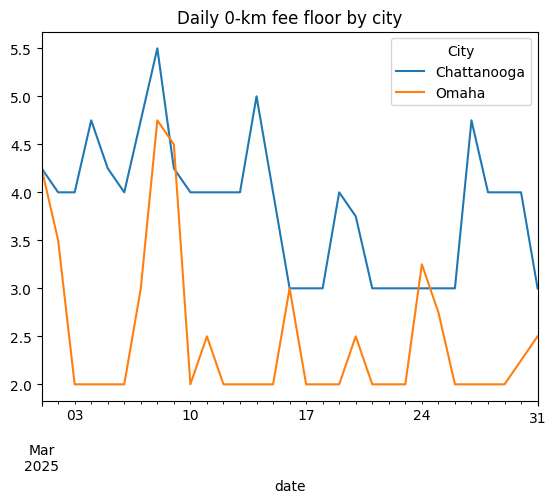

In [ ]:
floor = (df[df["Distance(KM)"] == 0]
         .groupby(["City", "date"])["DeliveryFee($)"].min()
         .unstack("City"))
floor.plot(title="Daily 0-km fee floor by city")  # flat = stable base
print(floor.nunique())  # 1 per city => base never changed in March